# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [1]:
# Install required packages (if not available on server, uncomment the lines below)
'''
!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib
'''


'\n!pip3 install --upgrade pip\n!pip3 install getdist\n!pip3 install numpy\n!pip3 install scipy\n!pip3 install matplotlib\n'

In [4]:
#Due to error I had to add this install line
!python -m pip install getdist

   ---------------------------------------- 0.0/834.0 kB ? eta -:--:--
   ------------------------- -------------- 524.3/834.0 kB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 834.0/834.0 kB 2.7 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a} 
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

Comment:


We define the Hubble function that takes all the necessary arguments (variables) in Friedmann equation.
The return is Hubble rate (H) based on the Friedmann equation, but because a = 1/(1+z) we make use of negative exponential and in equation we write (1+z)**exp with exp > 0.
After that, we define all of the necessary variables (based on the found papers and formula sum(omegas) = 1) and run function with those values as input so for the given redshift value (z) we get the corresponding Hubble rate.

In [2]:
# Hubble rate
def Hubble(red_shift, omega_matter, omega_lambda, omega_k, H0):
    """Returns the Hubble rate at a given redshift (z) based on the Friedmann equation.
    Parameters:
    red_shift(float): the wavelength is streched by a factor of (1+z) compared to the wavelength at emisison
    omega_matter(float): the matter density parameter
    omega_lambda(float): the dark energy density parameter
    omega_k(float): the curvature density parameter
    H0(float): the Hubble constant at present time (z=0)"""
    return np.sqrt(H0**2*(omega_lambda + omega_matter*(1+red_shift)**3 + omega_k*(1+red_shift)**2))

parsec = 3.086e16 #meters
h = 0.7 #dimensionless Hubble parameter
# H0 in SI units (1/s). 1 Mpc = 10^6 * parsec. 
# 100 km/s/Mpc -> (100 * 1000 m/s) / (10^6 * parsec)
H0_present = 70 #km/s/Mpc -> (70 * 1000 m/s) / (10^6 * parsec)
# currently accepted matter and dark energy density parameters for present time
omega_lam_present = 0.7
omega_matter_present = 0.3
omega_k_present = 0.0

# print Hubble rate at given parameters with scientific notation
# Using z=0 to verify H0 (should return H0)
print(f"H(z=0) = {Hubble(0, omega_matter_present, omega_lam_present, omega_k_present, H0_present):.3f} s^-1")

H(z=0) = 70.000 s^-1


Comment:

We will now proceed with plotting the Hubble rate for different values of redshift (z) in certain arbitrary range to see how the function acts.

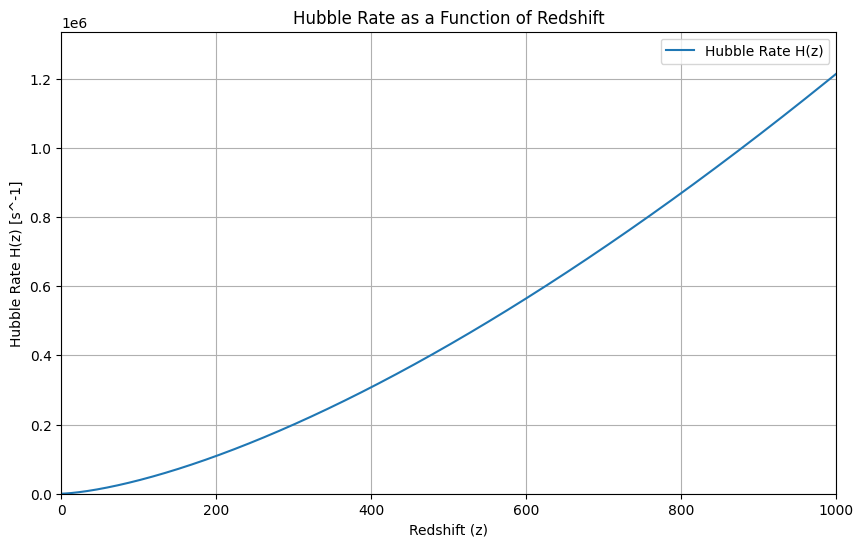

In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# In range z = [0, 1000] calculate Hubble rate using defined function and plot it
redshifts = np.linspace(0, 1000, 1000)
hubble_rates = Hubble(redshifts, omega_matter_present, omega_lam_present, omega_k_present, H0_present)

# plot the Hubble rate as a function of redshift
plt.figure(figsize=(10, 6))
plt.plot(redshifts, hubble_rates, label='Hubble Rate H(z)')
plt.xlabel('Redshift (z)')
plt.ylabel('Hubble Rate H(z) [s^-1]')
plt.title('Hubble Rate as a Function of Redshift')
plt.xlim(0, 1000) # Set x-axis upper and lower limit
plt.ylim(0, np.max(hubble_rates)*1.1) # set y-axis to go from 0 to 10% above the maximum hubble rate
plt.grid()
plt.legend()
plt.show()

We see that with fixed omega values, as redshift increases the rate increases which is expected since the higher expansion rate means the wavelength will be more strecthed (more redshifted).

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

Comment: 


For integration we will use [**Gaussian quadrature**](https://www.askpython.com/python-modules/numpy/gauss-legendre-quadrature-numpy) to approximate the integral value somewhat precisely. This numerical method is based on finding optimal points inside the integral range and finding function values in those points, assigning them their corresponding weights and summing them all up.
Gaussian Quadrature Formula:
$$\int_{a}^{b} f(x) dx \approx \frac{b-a}{2} \sum_{i=1}^{n} w_i f\left( \frac{b-a}{2}\xi_i + \frac{a+b}{2} \right)$$

In [4]:
# numerical method for integration - Gaussian quadrature approximation using pre-defined scipy function

import scipy
from scipy import integrate

# define speed of light in km/s
c = 2.998e5 # km/s

We will use this numerical method for integration inside our function for theoretical luminosity distance. Parameters taken for this function are redshift (which acts as the upper limit of our integral); 3 omega values (we  could have use only 2 parameters and calculate omega_k = 1 - omega_lam - omega_m; but because it is omega_k that defines which case function to use, it seems convenient for user to set all 3 values, and be sure that the input value of each omega is the desired one), and H_0 as present Hubble rate.


We implement mathematics in our function in 3 steps.
1. we calculate the integral value and multiply it by H_0 to get D_z
2. We compare Omega_k to 0 and choose our case function accoridngly
3. We insert chosen case function into the final formula

In [5]:

def theor_luminosity_distance(red_shift, omega_matter, omega_lambda, omega_k, H0):

    """Calculate the integral part first using scipy function
    define function lambda of z being 1/Hubble(z) with already defined Hubble function
    take the integral of this lambda function with z ranging from 0 to chosen redshift
    Calculate D_z by multiplying integral value with given H_0.
    We check if the given omega_k value is >,= or < 0 and take appropriate function in each case
    Following the given formula we then multiply this case function with (1+redshfit)*c/H_0
    This result is our theoretical luminosity distance in Megaparsecs

    Parameters: 
    red_shift: z (upper limit of our integral)
    omega_matter: matter density parameter
    omega_lambda: dark energy density parameter
    omega_k: curvature (0 if universe is flat)
    H_0: Hubble rate at present time

    Output: Theoretical Luminosity Distance in Mpc"""

    integral_val, error = integrate.quad(lambda z: 1/Hubble(z, omega_matter, omega_lambda, omega_k, H0), 0, red_shift)
    D_z = H0 * integral_val

    if omega_k > 0:
        sqrt_ok = np.sqrt(omega_k)
        case_function = (1/sqrt_ok) * np.sinh(sqrt_ok * D_z)

    elif omega_k == 0:
        case_function = D_z

    elif omega_k < 0:
        sqrt_ok = np.sqrt(-omega_k)
        case_function = (1/sqrt_ok) * np.sin(sqrt_ok * D_z)

    # Result in Mpc
    d_L_Mpc = (1 + red_shift) * (c / H0) * case_function
    
    return d_L_Mpc

# print function
# Using the standard parameters (Omega_m=0.3, Omega_L=0.7) to match expected value ~6607 Mpc
print(f"{theor_luminosity_distance(1, omega_matter_present, omega_lam_present, omega_k_present, H0_present):.3f} Mpc")

6607.824 Mpc


## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [6]:
import os, io, urllib.request

dataloc = "SCPUnion2.1_mu_vs_z.txt"  # local file

# If local file not found, download from Wayback Machine (original URL is down)
if not os.path.exists(dataloc):
    print("Local file not found, downloading from Wayback Machine...")
    url = "https://web.archive.org/web/2023id_/http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    response = urllib.request.urlopen(req)
    content = response.read().decode()
    with open(dataloc, 'w') as f:
        f.write(content)
    print("Downloaded and saved locally.")

# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
data = np.genfromtxt(dataloc)

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')
display(data[0])

array([           nan, 2.84880000e-02, 3.53465834e+01, 2.23905933e-01,
       1.28418942e-01])

In [7]:
#dataloc = "http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"

# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
#data = np.genfromtxt(dataloc)

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')
#display(data[0])

In [8]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...
zs = data[:,1] # redshift
#print(len(zs))
# ...or transpose the array and then slice by row: arr_transposed[n]
distance_modulus = data.T[2] # distance modulus
error_distance_modulus = data.T[3] # errors on distance modulus = sigmas

In [9]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
#     array_2 = some_function_of(array_1)

# luminosity distance in pc
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6

# and the error on that distance:
error_luminosity_distance_Mpc = 5. * (10.**((distance_modulus + error_distance_modulus)/5.-6.) - 10.**((distance_modulus - error_distance_modulus)/5.-6.))

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

Comment:


We plot both luminosity distance and distance modulus as a function of redshift, presenting 2 plots inside 1 figure. Since we have their respective errors from the data we will use plt.errorbar where we define which row/column or part of array is our x value (in this case it is "zs") and which one is y value (luminosity_distance_Mpc and distance_modulus). We define errors by setting yerr (y erros) to be respective error arrays (error_luminosity_distance_Mpc or error_distance_modulus).

technical details:
By using fmt and markersize we format visualization of our data to be filled circles (points) of defined size.

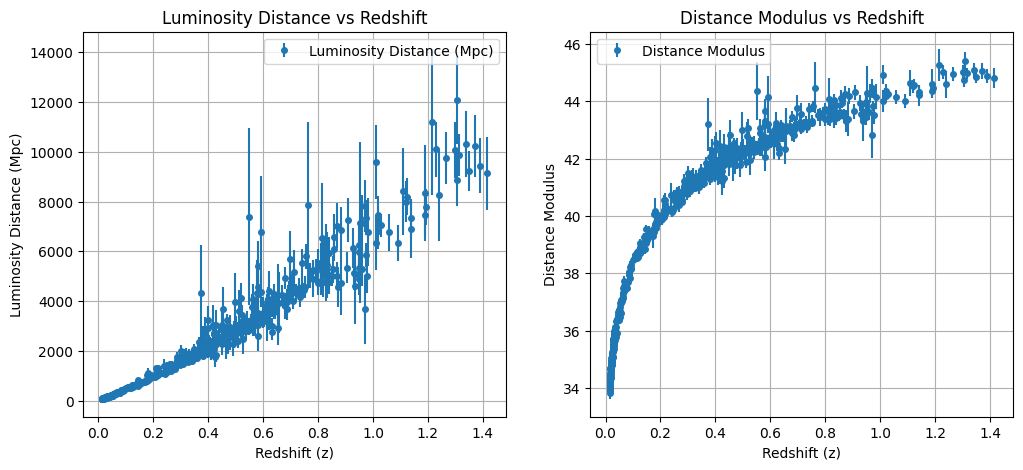

In [10]:
%matplotlib inline
# plot the luminosity distance and distance modulus as functions of the redshift
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt="o", markersize=4, label="Luminosity Distance (Mpc)")
plt.xlabel("Redshift (z)")
plt.ylabel("Luminosity Distance (Mpc)")
plt.title("Luminosity Distance vs Redshift")
plt.grid()
plt.legend()
plt.subplot(1,2,2)
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt="o", markersize=4, label="Distance Modulus")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus")
plt.title("Distance Modulus vs Redshift")
plt.grid()
plt.legend()

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

Comment:


Since we have alreay defined theoretical luminosity distance and we are given formula that connects it to the theoretical distance modulus, it is possible to use theor_luminosity_distance to define theor_distance_modulus. We set the same input parameters in both functions (because of the math, physics and computer science), outter function (distance modulus) will take input parameters given when called and those will then be taken as parameters inside inner theoretical luminosity distance function.

For our function to be able to deal with arrays (so that we don´t have to use the loop), we can use np.vectorization; creating vectorized function which can take numpy arrays as input.
When function is called we can set all the parameters by ourselves or use predefined variables (e.g. omega_lam_present). Output of such function is again numpy array.

In [11]:
# Use already defined function of luminosity distance to calculate the theoretical distance modulus

def theor_distance_modulus(z, om_matter, om_lambda, om_k, H_0):
    # Formula: mu = 5 * log10(d_L / 10pc)
    # Since d_L is in Mpc, we need: mu = 5 * log10(d_L[Mpc]) + 25
    return 5 * np.log10(theor_luminosity_distance(z, omega_matter=om_matter, omega_lambda=om_lambda, omega_k=om_k, H0=H_0)) + 25

# Vectorize the function to handle arrays of redshifts
theor_distance_modulus_vec = np.vectorize(theor_distance_modulus)

# run the function for the redshifts in the data, using the present parameters for omega and H0
# numpy array of theoretical distance moduli for the given redshift range
theoretical_distance_moduli = theor_distance_modulus_vec(zs, om_matter=0.3, om_lambda=0.7, om_k=0.0, H_0=70)

Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

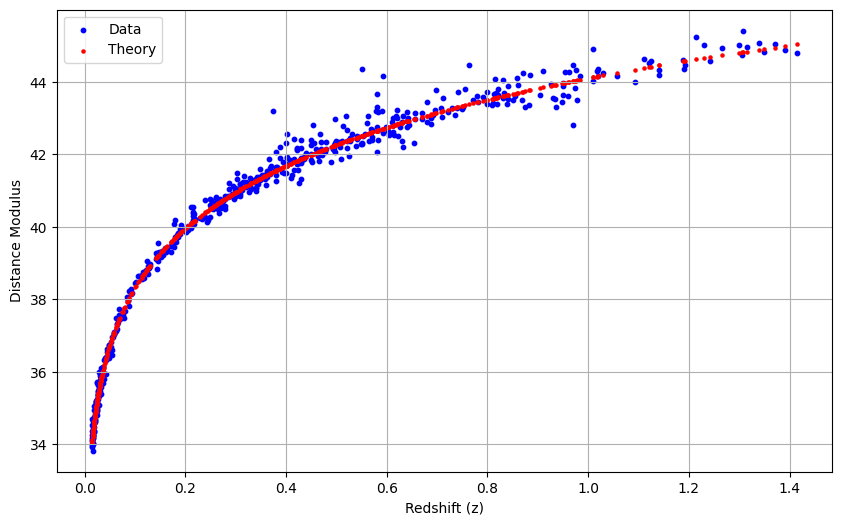

In [12]:
# plot the theoretical distance moduli as a function of redshift
# make it a scatter plot (data=blue, theory=red)
# in style make points small and lines thin so that it is easier to observe

plt.figure(figsize=(10, 6))
plt.scatter(zs, distance_modulus, c='blue', label='Data', s=10)
plt.scatter(zs, theoretical_distance_moduli, c='red', label='Theory', s=5)
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus')
plt.grid()
plt.legend()
plt.show()


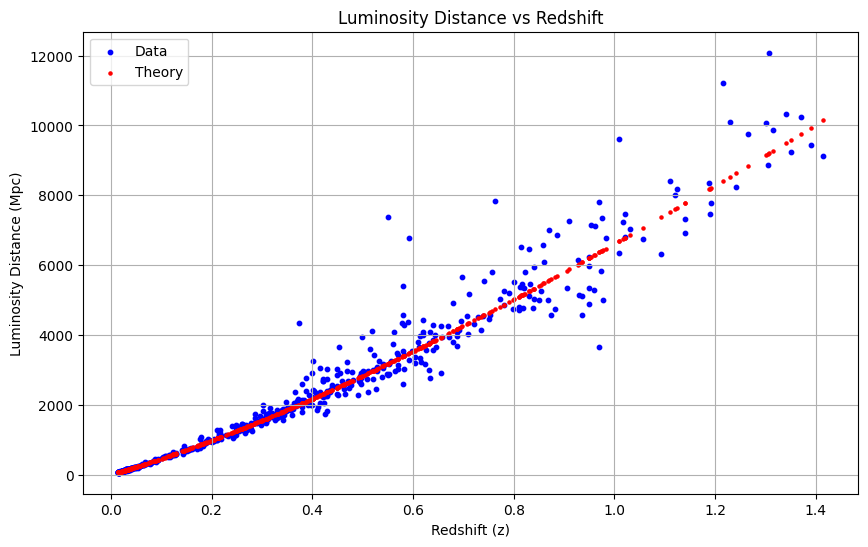

In [13]:
%matplotlib inline
# plot theoretical luminosity distance as a function of redshift
# also plot the data points from the supernovae
# make it a scatter plot (data=blue, theory=red)

# Vectorize the luminosity distance function to handle arrays
theor_luminosity_distance_vec = np.vectorize(theor_luminosity_distance)

theoretical_luminosity_distances = theor_luminosity_distance_vec(zs, omega_matter_present, omega_lam_present, omega_k_present, H0_present)

plt.figure(figsize=(10, 6))
plt.scatter(zs, luminosity_distance_Mpc, c='blue', label='Data', s=10)
plt.scatter(zs, theoretical_luminosity_distances, c='red', label='Theory', s=5)
plt.xlabel('Redshift (z)')
plt.ylabel('Luminosity Distance (Mpc)')
plt.title('Luminosity Distance vs Redshift')
plt.grid()
plt.legend()
plt.show()

Comment:


We plotted our data (blue points) and theoretical luminosity distances, and distance moduli. From both graphs it is reasonable to say that values from our theoretical functions match the data sufficiently enough, since the shape of the graph that our theoretical values follow more or less desribes the relation of data values between redshift and observed quantities.

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

Comment:

First we define a function to calculate chi_2 by inputing theta (a list of 3 inital parameters). Omega_k is gathered from sum(omega)=1. We take this parameters and an array of redshifts (zs) to calculate theoretical distance moduli (using defined vectorized function). We also take moduli values from our experimental data and calculated chi squared using provided formula.


MCMC
We start our MCMC algorithm by setting some inital theta values (whichever we like) as our parameters.
Calculate chi2 for those inital parameters
Define number of steps we are going to take and std for our step sizes

We start a loop in range of number of steps where we create proposed new values for our parameters based on gaussian distribution with inital parameter values as respective mean values and defined std. Our new proposals are randomly selected from this gaussian distributions.

Proposals are then "tested" to be accepted or not. First we check if omega_m is <0 in which case we set chi squared of proposal to be inifnity setting probability to 0 thus it gets declined.
Other than that, we consider all the other values to be equally probable making ratio of old and new priors = 1. 



Metropolis Hastings



We calculate chi squared for proposed parameters and get the difference between chi squared values of new and old parameters. If delta chi is < 0 => (meaning the new parameters are more probable) we automatically accept them (we want to have as much as possible more probable recorded steps(proposals) to get proper distribution of our parameter values). Otherwise, we don't decline step proposal immediately, but we first calculate probability for it to be accepted (using the formula provided and taking into account prior ratio = 1). Then we pick random number from 0 to 1 and in case it is smaller than our probability value -> we accept proposal.


In case proposal is accepted; we set proposed parameter values as our new inital values and our accpetence counter increases by 1.


After each step we write down our initals. In case they were not changed we write them again which increases frequency of more probable proposals in our output file. This is necessary to achieve proper distributions for our parameter values.

In [14]:
from random import random
from random import gauss
import sys
import time

def calculate_chi2(theta):
    """Calculate the chi-squared value for the given parameters
    it is a sum of squared differences between theoretical distance moduli
    based on the input parameters; and observed distance moduli
    in the redshift range given by zs data
    parameters: list theta containing initial h, omega_m and omega_l value
    output: chi2 (chi squared) obtained by numpy sum"""
    
    # Unpack parameters: h, Omega_m, Omega_Lambda
    h_initial, Omega_m_initial, Omega_L_initial = theta
    
    # Calculate Omega_k based on flatness constraint: sum(Omega) = 1
    # Omega_k = 1 - Omega_m - Omega_Lambda
    Omega_k_initial = 1.0 - Omega_m_initial - Omega_L_initial
    
    # Convert 'h' (dimensionless) to H0 (km/s/Mpc)
    H0_curr = 100.0 * h_initial

    # Calculate theoretical distance moduli for all redshifts using the vectorized function
    # zs, distance_modulus, error_distance_modulus are global variables defined in previous cells
    mu_theoretical = theor_distance_modulus_vec(zs, Omega_m_initial, Omega_L_initial, Omega_k_initial, H0_curr)
    
    # Calculate Chi-Squared: sum(((model - obs) / error)^2)
    chi2 = np.sum(((mu_theoretical - distance_modulus) / error_distance_modulus)**2)
    
    return chi2

filename = "MC_Chain_SNIa.txt"
file = open(filename,"w")

# define Initial guess/value parameters
# Starting parameters: h, Omega_m, Omega_Lambda
# Starting with a bad guess to demonstrate convergence
theta_initial = [0.1, 0.2, 0.3] # (h, Omega_m, Omega_L) intentionally far
chi2_initial = calculate_chi2(theta_initial)

print("Progress: ") # so we don't get bored while waiting...
start = time.time()

# MCMC parameters (number of steps, size of each step, count for accepted steps(proposals))
N_steps = 10000  # Number of steps in the chain (increase for better sampling)
step_sizes = [0.01, 0.01, 0.01]  # Standard deviation for Gaussian proposal for [h, Om, OL]
accepted_count = 0 # counts accepted steps (proposals)

for i in range(N_steps):
    # Propose new parameters using Gaussian distribution
    # For each parameter we set its initial value as mean and set std
    # this gaussian distribution is our probability distribution of the step size
    # step size is randomly selected based on this distribution
    theta_proposed = [
        gauss(theta_initial[0], step_sizes[0]),
        gauss(theta_initial[1], step_sizes[1]),
        gauss(theta_initial[2], step_sizes[2])
    ]
    
    # Check Constraints / Priors
    # e.g. Matter density cannot be negative
    if theta_proposed[1] < 0:
        chi2_proposed = np.inf # set to infinity to make probability go to 0
    else:
        chi2_proposed = calculate_chi2(theta_proposed) # use chi2 function on proposed parameters
    
    # 3. Metropolis-Hastings Acceptance Step
    delta_chi2 = chi2_proposed - chi2_initial
    
    accept = False # initially set as false -> don't accept
    if delta_chi2 < 0:
        # Better fit (lower chi2) -> Always accept
        accept = True
    else:
        # Worse fit -> Accept with probability exp(-delta_chi2 / 2)
        probability = np.exp(-0.5 * delta_chi2)
        # only constraint we have is that omega_m can't be < 0
        # other than that we don't know/assume anything about parameters
        # this makes any values equally probable -> prior_old/prior_new = 1
        if random() < probability: # random() takes number [0,1)
            accept = True
    
    # Update state if accepted
    if accept:
        theta_initial = theta_proposed
        chi2_initial = chi2_proposed
        accepted_count += 1
    
    # Save to file
    # Format tablelike structure -> index | h | Omega_m | Omega_Lambda | chi2
    file.write(f"{i} {theta_initial[0]:.5f} {theta_initial[1]:.5f} {theta_initial[2]:.5f} {chi2_initial:.5f}\n")
    
    # Print progress (step, chi2 and accept rate) every 50 steps
    if (i+1) % 50 == 0:
        print(f"Step {i+1}/{N_steps} | Chi2: {chi2_initial:.3f} | Accept Rate: {accepted_count/(i+1):.3f}")

print("Finally! Acceptance ratio = ", accepted_count/N_steps) # number of steps whose proposal got accepted / total number of steps
file.close()

end = time.time()
print('time required: {:.3f} s'.format(end-start))

Progress: 
Step 50/10000 | Chi2: 38855.371 | Accept Rate: 0.620
Step 100/10000 | Chi2: 3722.988 | Accept Rate: 0.560
Step 150/10000 | Chi2: 632.342 | Accept Rate: 0.547
Step 200/10000 | Chi2: 601.487 | Accept Rate: 0.460
Step 250/10000 | Chi2: 590.055 | Accept Rate: 0.392
Step 300/10000 | Chi2: 586.715 | Accept Rate: 0.343
Step 350/10000 | Chi2: 573.031 | Accept Rate: 0.334
Step 400/10000 | Chi2: 565.833 | Accept Rate: 0.328
Step 450/10000 | Chi2: 570.117 | Accept Rate: 0.313
Step 500/10000 | Chi2: 568.565 | Accept Rate: 0.310
Step 550/10000 | Chi2: 567.152 | Accept Rate: 0.295
Step 600/10000 | Chi2: 567.968 | Accept Rate: 0.293
Step 650/10000 | Chi2: 565.741 | Accept Rate: 0.291
Step 700/10000 | Chi2: 563.531 | Accept Rate: 0.297
Step 750/10000 | Chi2: 564.958 | Accept Rate: 0.295
Step 800/10000 | Chi2: 567.915 | Accept Rate: 0.295
Step 850/10000 | Chi2: 563.869 | Accept Rate: 0.293
Step 900/10000 | Chi2: 563.521 | Accept Rate: 0.291
Step 950/10000 | Chi2: 562.993 | Accept Rate: 0.285

01`After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.7`

`0.288     0.712    0.699`

`...`

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

(7000, 4)
Removed no burn in
0.69  <  h  <  0.7  at  68% CL
0.17  <  OmegaM  <  0.3  at  68% CL
0.56  <  OmegaL  <  0.74  at  68% CL
-0.03  <  Omegak  <  0.26  at  68% CL




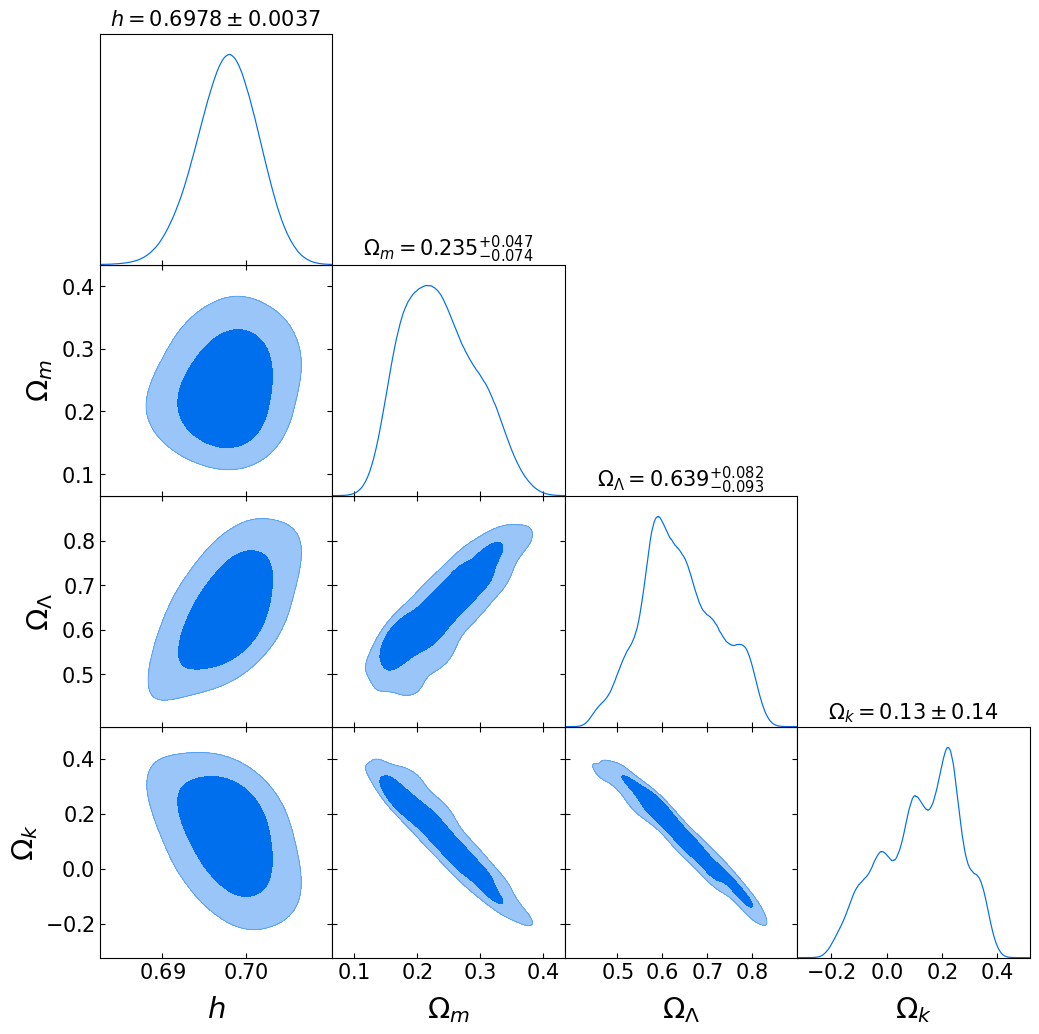

In [15]:
filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename,
                      skiprows=int(0.3 * N_steps)) # remove some burn-in

h, OmegaM, OmegaL, chi2 = datafile[:,1], datafile[:,2], datafile[:,3], datafile[:,4]

# You can easily create new np.arrays that are functions of other np.arrays
Omegak = 1. - OmegaM - OmegaL

# Let's define variable names and labels
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names = ['h', 'OmegaM', 'OmegaL', 'Omegak']
my_dim = len(my_names) # The number of variables we're plotting

# This creates a higher-dimensional array with all our data, shaped in the appropriate way...
my_samples = np.transpose(np.reshape([h, OmegaM, OmegaL, Omegak], (my_dim, len(h))))
print(np.shape(my_samples))

# ... to create an "MCSamples" data type, which GetDist can use
my_samples = MCSamples(samples = my_samples, labels = my_labels, names = my_names)

# The usual 1-sigma confidence level. You can change to 2- or 3-sigma if you want
conf_level = 0.6827

# This prints a table with the 1D posteriors (confidence levels)
for nam in my_names:
    print(round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=False),2), \
          " < ", nam , " < ", round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=True),2),\
          " at " , int(100*conf_level),"\b% CL")
print("\n")

#Triangle corner plot
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize = 16
j.triangle_plot(my_samples, filled = True, title_limit=1)

In [16]:
print(my_samples.getParamNames())

h	h
OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
Omegak	\Omega_k



##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces. 

For each parameter distribution, mean is that value which was most probable and thus during MCMC ended up being the most frequent one in our output file. Therefore, it is reasonable to take mean values as our best fit for each parameter. We then use our vectorized function to get $\mu$ based on our best fit parameters in an arbitrary range of redshift. We set confidence intervals as by defining $\mu$ with min/max values of our parameters.


Plotting


We plot the data points with corresponing errors using plt.errorbar for "zs" values of redshift and we plot our theoretical best fit in pre-defined range using plt.plot to get a continuous line. In addition we plot confidence interval using plt.fill_between in between calculated $\mu$ values for min/max parameters.
In addition, log scale values were plotted for better representation of correlation and residuals were calculated = model - data for each redshift value in "zs".

h_best: 0.698, Omega_M_best: 0.235, Omega_L_best: 0.639


<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_25228\390983071.py:55: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Distance Modulus $\mu$')


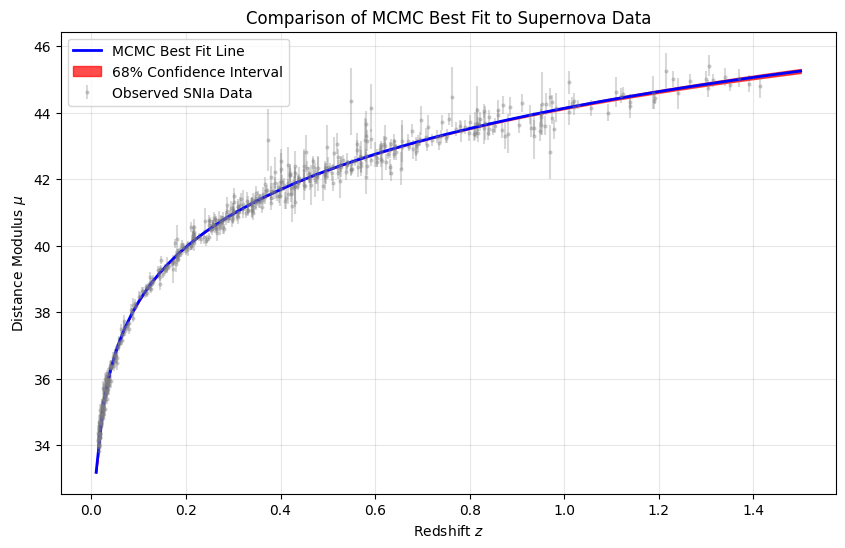

In [17]:

##Example of how to get the confidence intervals from your MCMC samples
h_min = my_samples.confidence('h',(1.-conf_level)/2.,upper=False)
h_max = my_samples.confidence('h',(1.-conf_level)/2.,upper=True)
Omega_M_min = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=False)
Omega_M_max = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=True)
Omega_L_min = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=False)
Omega_L_max = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=True)




##<-- YOUR CODE GOES HERE!  calculate d_L and mu as a function of z using the best fit parameters from MCMC

# Define the best-fit parameters (by the means of the samples)
h_best = my_samples.getMeans()[0]
Omega_M_best = my_samples.getMeans()[1]
Omega_L_best = my_samples.getMeans()[2]
Omega_k_best = 1.0 - Omega_M_best - Omega_L_best
H0_best = 100.0 * h_best

# Generate a redshift range for plotting the theoretical curve
z_range = np.linspace(0.01, 1.5, 100) # start, stop, number of points

# Calculate theoretical distance modulus for the best fit
mu_best = theor_distance_modulus_vec(z_range, Omega_M_best, Omega_L_best, Omega_k_best, H0_best)

# Calculate mu for the confidence interval boundaries (error)
# We use the min/max values found above to define the error range
mu_low = theor_distance_modulus_vec(z_range, Omega_M_min, Omega_L_min, 1-Omega_M_min-Omega_L_min, 100*h_min)
mu_high = theor_distance_modulus_vec(z_range, Omega_M_max, Omega_L_max, 1-Omega_M_max-Omega_L_max, 100*h_max)



#print best fit values coming from MCMC
print(f"h_best: {h_best:.3f}, Omega_M_best: {Omega_M_best:.3f}, Omega_L_best: {Omega_L_best:.3f}")



# plot your d_L and mu together with the data to compare
plt.figure(figsize=(10, 6))

# Plot the 580 observed data points
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, 
             fmt='o', color='grey', markersize=2, alpha=0.3, 
             label='Observed SNIa Data')

# Plot the best-fit curve from MCMC
plt.plot(z_range, mu_best, color='blue', lw=2, label='MCMC Best Fit Line')

# Plot the 68% confidence interval as a region
plt.fill_between(z_range, mu_low, mu_high, color='red', 
                 alpha=0.7, label='68% Confidence Interval')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance Modulus $\mu$')
plt.title('Comparison of MCMC Best Fit to Supernova Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_25228\2503225391.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Distance Modulus $\mu$')
C:\Users\HP\AppData\Local\Temp\ipykernel_25228\2503225391.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$\mu_{obs} - \mu_{theor}$')


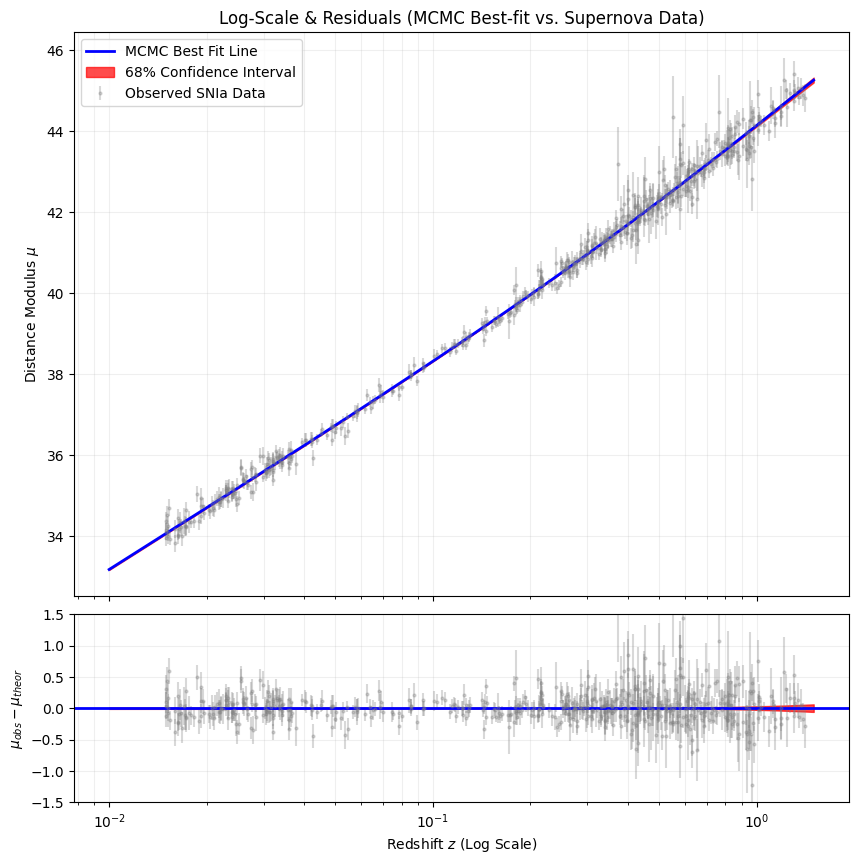

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
plt.subplots_adjust(hspace=0.05)

# Log Scale
ax1.errorbar(zs, distance_modulus, yerr=error_distance_modulus, 
             fmt='o', color='gray', markersize=2, alpha=0.3, label='Observed SNIa Data')
ax1.plot(z_range, mu_best, color='blue', lw=2, label='MCMC Best Fit Line')
ax1.fill_between(z_range, mu_low, mu_high, color='red', alpha=0.7, label='68% Confidence Interval')

ax1.set_xscale('log')
ax1.set_ylabel('Distance Modulus $\mu$')
ax1.set_title('Log-Scale & Residuals (MCMC Best-fit vs. Supernova Data)')
ax1.legend()
ax1.grid(which='both', alpha=0.2)

# Residuals (Data - Model)
# Calculate the model prediction at the exact redshifts of the 580 data points
mu_model_at_zs = theor_distance_modulus_vec(zs, Omega_M_best, Omega_L_best, Omega_k_best, H0_best)
residuals = distance_modulus - mu_model_at_zs

ax2.errorbar(zs, residuals, yerr=error_distance_modulus, fmt='o', color='gray', markersize=2, alpha=0.3)
ax2.axhline(0, color='blue', lw=2) # 0 line represents a perfect fit

# Calculate the uncertainty band for the residuals
res_low = mu_low - mu_best[0] # Approximating the relative width
res_high = mu_high - mu_best[0]
# use the difference between the bounds and the best fit
ax2.fill_between(z_range, mu_low - mu_best, mu_high - mu_best, color='red', alpha=0.7)

ax2.set_xlabel('Redshift $z$ (Log Scale)')
ax2.set_ylabel('$\mu_{obs} - \mu_{theor}$')
ax2.set_ylim(-1.5, 1.5) # Zoom in
ax2.grid(which='both', alpha=0.2)

plt.show()